# 02 - Tăng cường ảnh X-quang phổi (Phần b)

Các kỹ thuật tăng cường tương phản/độ nét phù hợp ảnh y tế: Histogram Equalization, CLAHE,
Gamma correction, Unsharp masking, và pipeline đề xuất (CLAHE + khử nhiễu nhẹ).

In [1]:
import os
import random

import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from utils import list_dataset, load_gray, save_result, CLASSES

random.seed(42)
%matplotlib inline

## Các hàm tăng cường ảnh

In [2]:
def hist_eq(img):
    """Histogram Equalization toàn cục - baseline so sánh."""
    return cv2.equalizeHist(img)


def clahe_enhance(img, clip_limit=2.0, tile_grid_size=(8, 8)):
    """CLAHE - tăng tương phản cục bộ, hạn chế khuếch đại nhiễu. Chuẩn cho ảnh y tế."""
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    return clahe.apply(img)


def gamma_correction(img, gamma=1.5):
    """gamma > 1: làm sáng vùng tối; gamma < 1: làm tối vùng sáng."""
    inv_gamma = 1.0 / gamma
    table = np.array([((i / 255.0) ** inv_gamma) * 255 for i in range(256)]).astype("uint8")
    return cv2.LUT(img, table)


def unsharp_mask(img, sigma=2.0, amount=1.5):
    """Làm rõ nét các vệt mờ phổi bằng unsharp masking."""
    blurred = cv2.GaussianBlur(img, (0, 0), sigma)
    sharpened = cv2.addWeighted(img, 1 + amount, blurred, -amount, 0)
    return sharpened


def recommended_pipeline(img):
    """CLAHE (tăng tương phản cục bộ) + khử nhiễu nhẹ - tránh khuếch đại nhiễu quá mức."""
    enhanced = clahe_enhance(img)
    return cv2.medianBlur(enhanced, 3)

## 1. So sánh trực quan

Ảnh gốc vs từng kỹ thuật, kèm histogram cường độ pixel để minh chứng định lượng.

In [3]:
samples = {}
for cls in CLASSES:
    items = list_dataset([cls])
    samples[cls] = random.choice(items)

samples

{'COVID': ('COVID',
  '/home/sonnguyen/processing_python/raw_data/COVID-19_Radiography_Dataset/COVID/images/COVID-3356.png',
  '/home/sonnguyen/processing_python/raw_data/COVID-19_Radiography_Dataset/COVID/masks/COVID-3356.png'),
 'Lung_Opacity': ('Lung_Opacity',
  '/home/sonnguyen/processing_python/raw_data/COVID-19_Radiography_Dataset/Lung_Opacity/images/Lung_Opacity-182.png',
  '/home/sonnguyen/processing_python/raw_data/COVID-19_Radiography_Dataset/Lung_Opacity/masks/Lung_Opacity-182.png'),
 'Normal': ('Normal',
  '/home/sonnguyen/processing_python/raw_data/COVID-19_Radiography_Dataset/Normal/images/Normal-1193.png',
  '/home/sonnguyen/processing_python/raw_data/COVID-19_Radiography_Dataset/Normal/masks/Normal-1193.png'),
 'Viral Pneumonia': ('Viral Pneumonia',
  '/home/sonnguyen/processing_python/raw_data/COVID-19_Radiography_Dataset/Viral Pneumonia/images/Viral Pneumonia-295.png',
  '/home/sonnguyen/processing_python/raw_data/COVID-19_Radiography_Dataset/Viral Pneumonia/masks/Vir

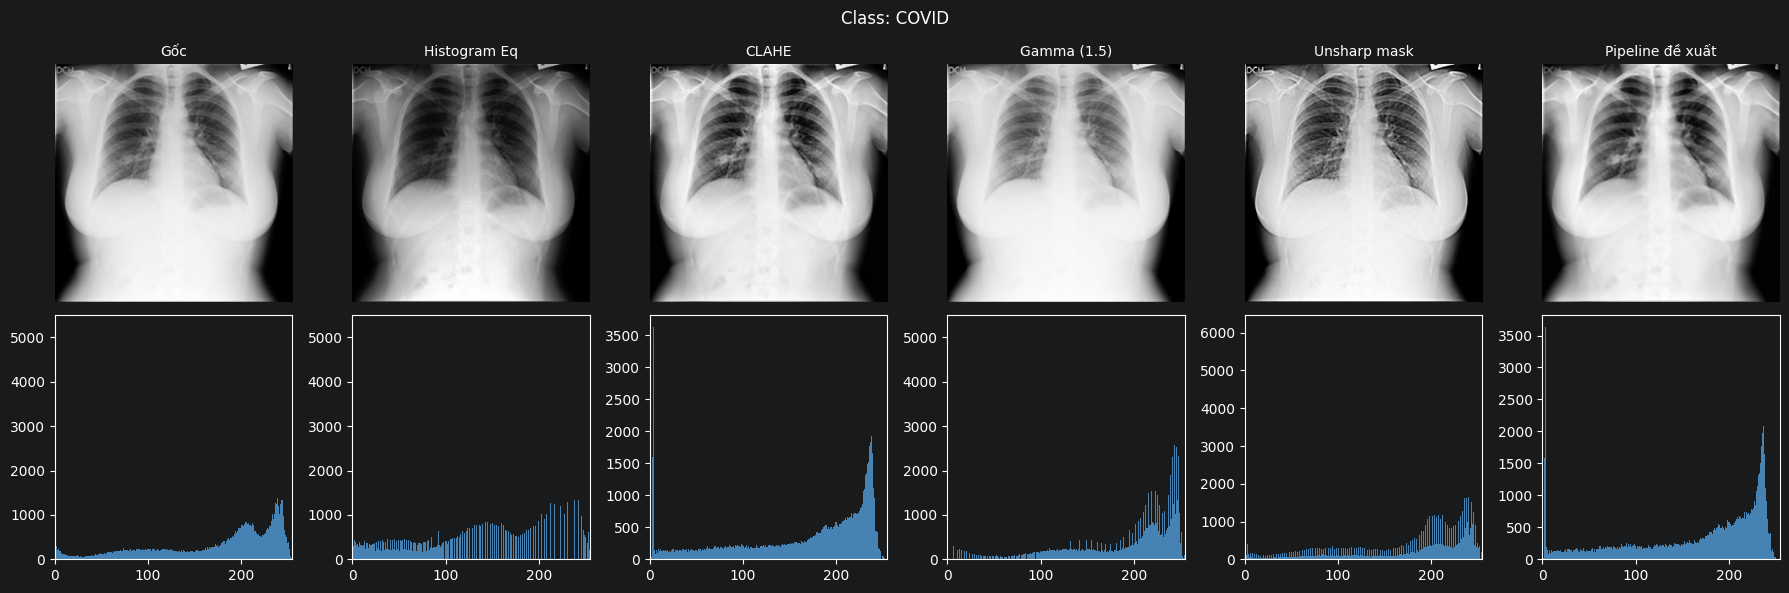

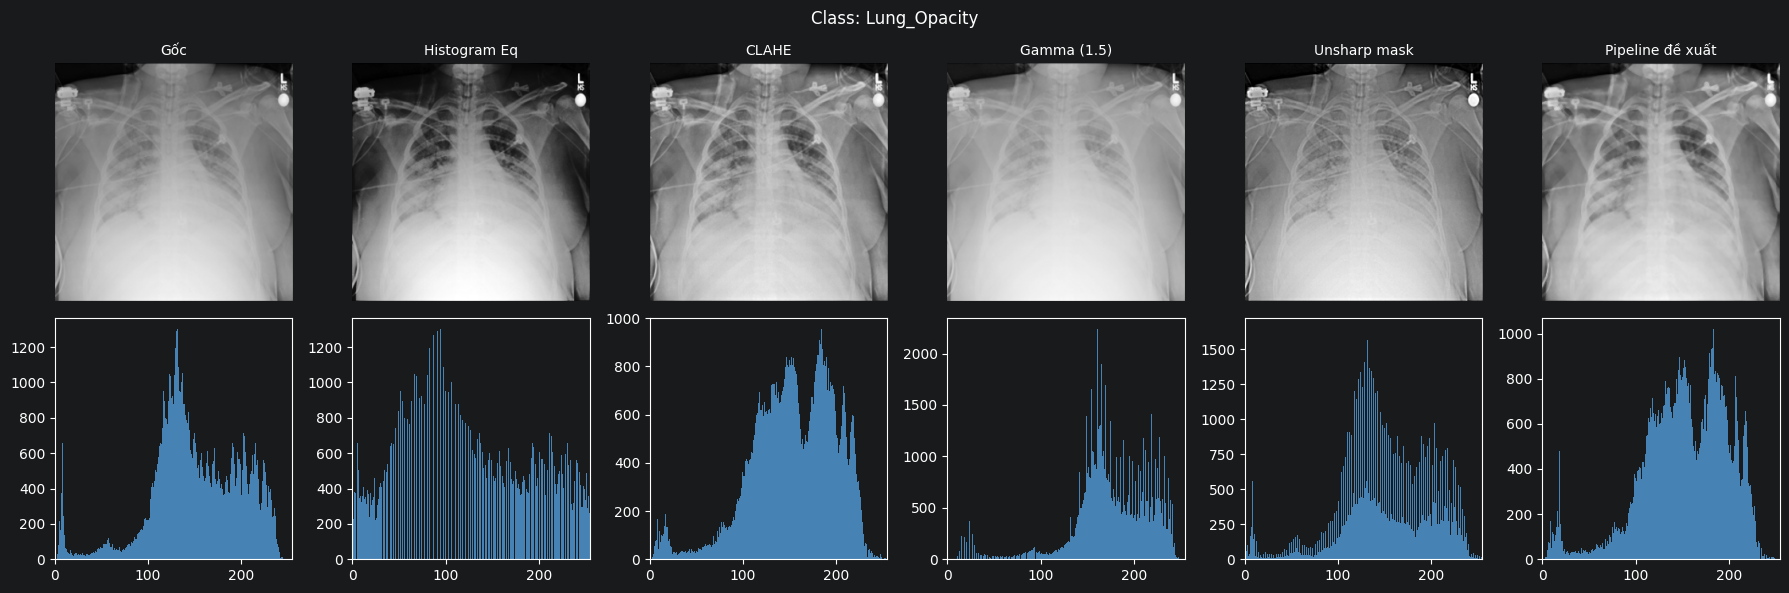

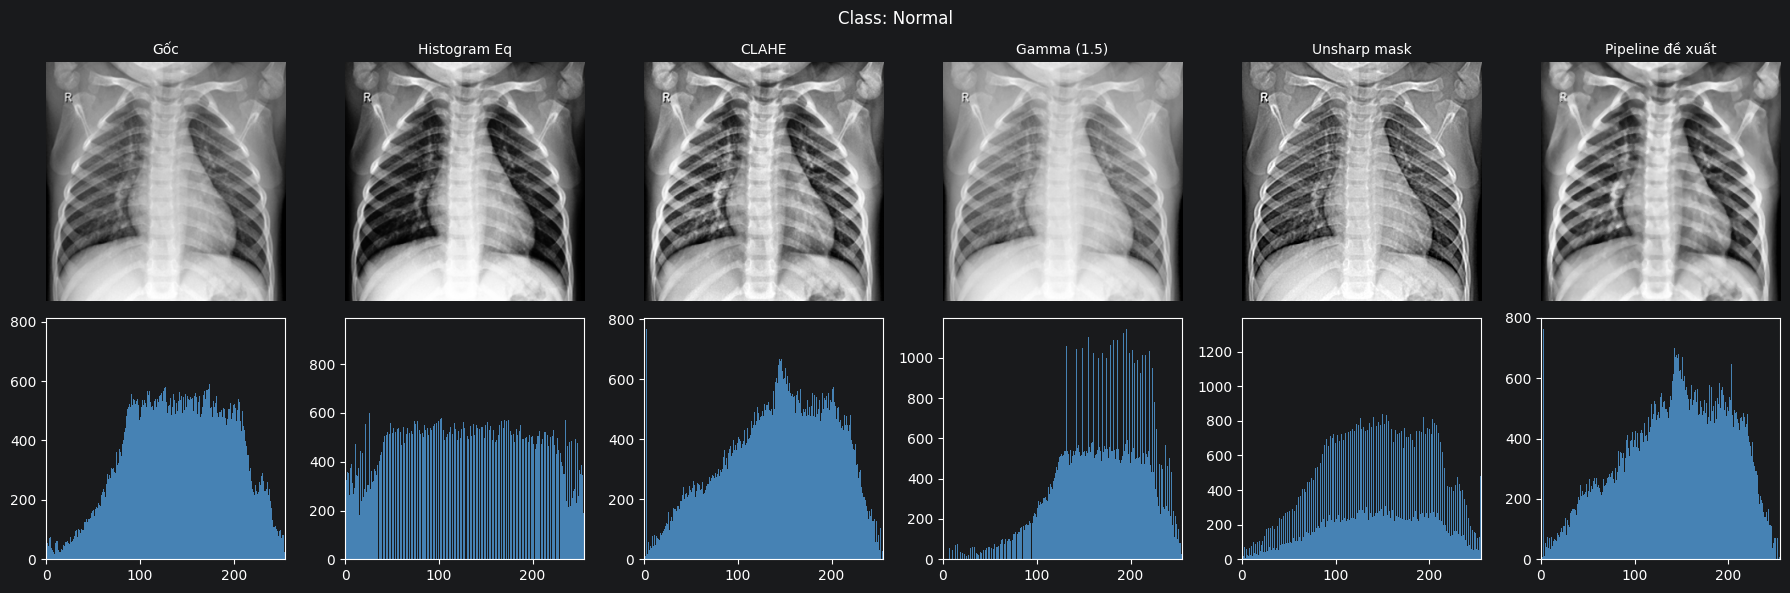

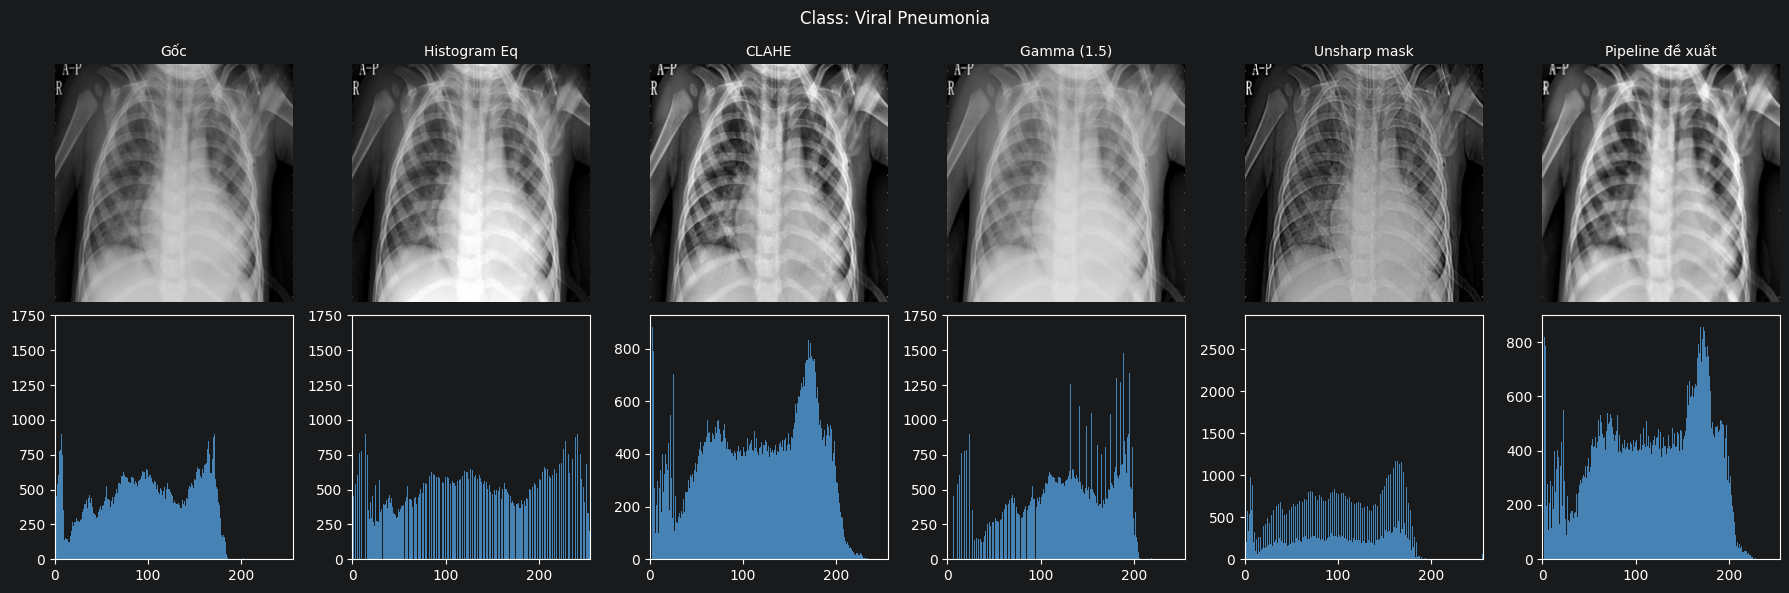

In [4]:
ENHANCEMENTS = {
    "Gốc": lambda img: img,
    "Histogram Eq": hist_eq,
    "CLAHE": clahe_enhance,
    "Gamma (1.5)": lambda img: gamma_correction(img, 1.5),
    "Unsharp mask": unsharp_mask,
    "Pipeline đề xuất": recommended_pipeline,
}

for cls, (_, img_path, _) in samples.items():
    img = load_gray(img_path)
    n = len(ENHANCEMENTS)
    fig, axes = plt.subplots(2, n, figsize=(3 * n, 6))
    for c, (name, fn) in enumerate(ENHANCEMENTS.items()):
        out = fn(img)
        axes[0][c].imshow(out, cmap="gray")
        axes[0][c].set_title(name, fontsize=10)
        axes[0][c].axis("off")
        axes[1][c].hist(out.ravel(), bins=256, range=(0, 255), color="steelblue")
        axes[1][c].set_xlim(0, 255)
    fig.suptitle(f"Class: {cls}")
    plt.tight_layout()
    plt.show()

## 2. Xử lý hàng loạt toàn bộ dataset

Áp dụng từng kỹ thuật lên toàn bộ 21,165 ảnh, lưu ra `output/enhanced/<technique>/<class>/`.

`LIMIT = None` nghĩa là chạy toàn bộ dataset. Đặt `LIMIT` thành một số nhỏ (vd. 5) để chạy thử nhanh trước.

In [5]:
LIMIT = 5  # sanity check trước - đổi thành None để chạy toàn bộ dataset

BATCH_TECHNIQUES = {
    "hist_eq": hist_eq,
    "clahe": clahe_enhance,
    "gamma": lambda img: gamma_correction(img, 1.5),
    "unsharp": unsharp_mask,
    "recommended_pipeline": recommended_pipeline,
}


def run_batch(limit=None):
    items = list_dataset()
    if limit:
        items = items[:limit]
    for technique, fn in BATCH_TECHNIQUES.items():
        for class_name, img_path, _ in tqdm(items, desc=technique):
            img = load_gray(img_path)
            result = fn(img)
            save_result(result, "enhanced", technique, class_name, os.path.basename(img_path))


run_batch(LIMIT)
print("Sanity check batch xong.")

hist_eq:   0%|          | 0/5 [00:00<?, ?it/s]

clahe:   0%|          | 0/5 [00:00<?, ?it/s]

gamma:   0%|          | 0/5 [00:00<?, ?it/s]

unsharp:   0%|          | 0/5 [00:00<?, ?it/s]

recommended_pipeline:   0%|          | 0/5 [00:00<?, ?it/s]

Sanity check batch xong.


In [6]:
# Chạy toàn bộ dataset (21,165 ảnh x 5 kỹ thuật). Có thể mất một lúc.
LIMIT = None
run_batch(LIMIT)
print("Batch xử lý toàn bộ dataset hoàn tất.")

hist_eq:   0%|          | 0/21165 [00:00<?, ?it/s]

clahe:   0%|          | 0/21165 [00:00<?, ?it/s]

gamma:   0%|          | 0/21165 [00:00<?, ?it/s]

unsharp:   0%|          | 0/21165 [00:00<?, ?it/s]

recommended_pipeline:   0%|          | 0/21165 [00:00<?, ?it/s]

Batch xử lý toàn bộ dataset hoàn tất.


## 3. Kiểm tra kết quả

Đối chiếu số lượng file output với số ảnh gốc mỗi lớp.

In [7]:
expected_counts = {cls: len(list_dataset([cls])) for cls in CLASSES}
for technique in BATCH_TECHNIQUES:
    print(f"--- {technique} ---")
    for cls in CLASSES:
        out_dir = os.path.join("output", "enhanced", technique, cls)
        actual = len(os.listdir(out_dir)) if os.path.isdir(out_dir) else 0
        status = "OK" if actual == expected_counts[cls] else "MISMATCH"
        print(f"  {cls}: {actual}/{expected_counts[cls]} [{status}]")

--- hist_eq ---
  COVID: 3616/3616 [OK]
  Lung_Opacity: 6012/6012 [OK]
  Normal: 10192/10192 [OK]
  Viral Pneumonia: 1345/1345 [OK]
--- clahe ---
  COVID: 3616/3616 [OK]
  Lung_Opacity: 6012/6012 [OK]
  Normal: 10192/10192 [OK]
  Viral Pneumonia: 1345/1345 [OK]
--- gamma ---
  COVID: 3616/3616 [OK]
  Lung_Opacity: 6012/6012 [OK]
  Normal: 10192/10192 [OK]
  Viral Pneumonia: 1345/1345 [OK]
--- unsharp ---
  COVID: 3616/3616 [OK]
  Lung_Opacity: 6012/6012 [OK]
  Normal: 10192/10192 [OK]
  Viral Pneumonia: 1345/1345 [OK]
--- recommended_pipeline ---
  COVID: 3616/3616 [OK]
  Lung_Opacity: 6012/6012 [OK]
  Normal: 10192/10192 [OK]
  Viral Pneumonia: 1345/1345 [OK]
